# Bayesian optimization

Some functions are **expensive** to evaluate: a lab experiment, a long simulation, the training of a large model. With only a few dozen evaluations available, grid search and random search waste most of them. **Bayesian optimization** (BO) uses every evaluation as efficiently as possible:

1. fit a probabilistic **surrogate model** (a Gaussian process) to the evaluations collected so far;
2. use it to compute an **acquisition function** that scores how useful it would be to evaluate each candidate point, balancing *exploitation* (where the model predicts high values) and *exploration* (where it is uncertain);
3. evaluate the function at the best candidate, add the result to the data, and repeat.

This notebook first runs BO step by step on a one-dimensional test function, compares three acquisition functions against random search, and then applies the method to a real design problem: making a **paper helicopter** fly as long as possible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from gp import GP, expected_improvement, upper_confidence_bound

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["figure.dpi"] = 100

## 1. Three acquisition functions

Given a GP posterior with mean $\mu(x)$ and standard deviation $\sigma(x)$, and the best value observed so far $f^*$:

- **Expected improvement (EI)**: $\mathbb{E}[\max(f(x) - f^*, 0)]$, the expected amount by which $x$ would beat the current best. It is large where the mean is high *or* the uncertainty is large.
- **Upper confidence bound (UCB)**: $\mu(x) + \beta \sigma(x)$, an optimistic estimate of $f(x)$. The parameter $\beta$ sets how much exploration is worth.
- **Thompson sampling (TS)**: draw one random function from the posterior and evaluate its maximizer. Exploration comes from the randomness of the sample.

We maximize the one-dimensional function

$$f(x) = -(6x - 2)^2 \sin(12x - 4), \qquad x \in [0, 1],$$

which has a sharp global maximum at $x \approx 0.757$ and a smaller local maximum near $x \approx 0.14$, starting from three random evaluations.

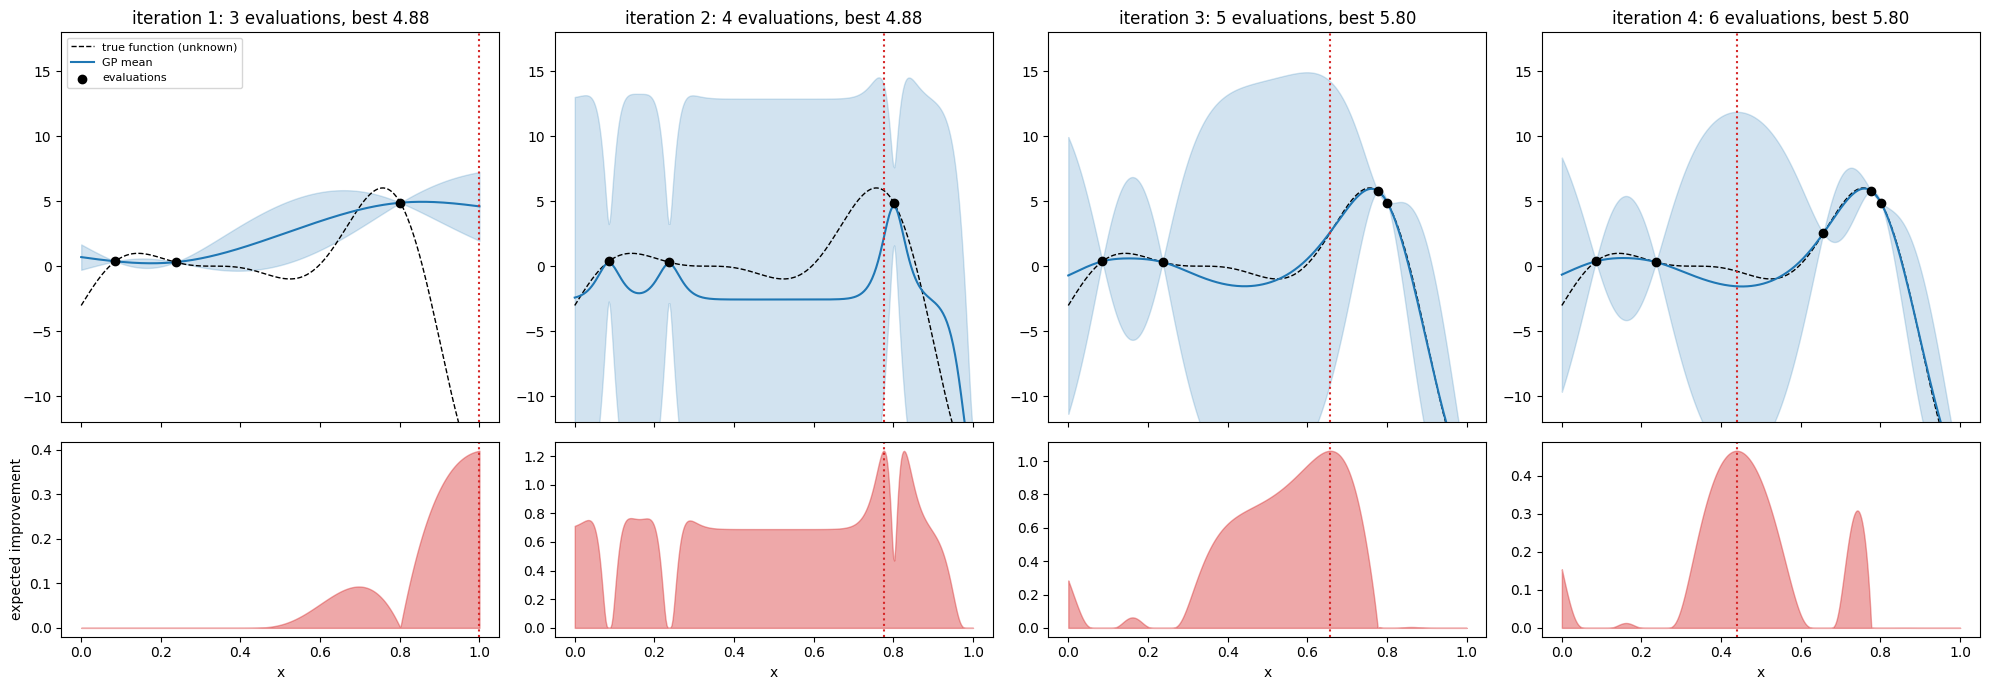

true maximum: 6.021; best found after 7 evaluations: 5.803


In [2]:
f = lambda x: -(6 * x - 2) ** 2 * np.sin(12 * x - 4)
grid = np.linspace(0, 1, 400)[:, None]
f_max = f(grid).max()

rng = np.random.default_rng(3)
X = rng.uniform(0, 1, (3, 1))
y = f(X).ravel()

fig, axes = plt.subplots(2, 4, figsize=(20, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for step in range(4):
    gp = GP("matern52").fit(X, y, restarts=5)
    mu, var = gp.predict(grid)
    ei = expected_improvement(gp, grid, y.max())
    x_next = grid[[ei.argmax()]]

    ax = axes[0, step]
    ax.plot(grid, f(grid), "k--", lw=1, label="true function (unknown)")
    ax.plot(grid, mu, color="tab:blue", label="GP mean")
    ax.fill_between(grid.ravel(), mu - 2 * np.sqrt(var), mu + 2 * np.sqrt(var), color="tab:blue", alpha=0.2)
    ax.scatter(X, y, color="black", zorder=3, label="evaluations")
    ax.axvline(x_next[0, 0], color="tab:red", ls=":")
    ax.set(title=f"iteration {step + 1}: {len(X)} evaluations, best {y.max():.2f}", ylim=(-12, 18))
    axes[1, step].fill_between(grid.ravel(), ei, color="tab:red", alpha=0.4)
    axes[1, step].axvline(x_next[0, 0], color="tab:red", ls=":")
    axes[1, step].set(xlabel="x", ylabel="expected improvement" if step == 0 else "")

    X = np.vstack([X, x_next])
    y = np.append(y, f(x_next).ravel())
axes[0, 0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()
print(f"true maximum: {f_max:.3f}; best found after {len(X)} evaluations: {y.max():.3f}")

Each column is one iteration; the red line marks the point chosen next, where the expected improvement (bottom row) is highest.

- At first the model sees a rising trend and probes the right edge of the domain, where it expects improvement.
- With a few more points the GP locates the peak near 0.8 and starts refining it, quickly reaching 5.80, close to the true maximum of 6.02.
- Once the peak is well described, EI shifts to the **unexplored** middle of the domain, where the posterior is very uncertain. It is checking that no higher peak is hidden there: this is exploration at work.

### Comparing strategies

A single run can be lucky. We repeat the optimization 20 times from different random starts, with 12 evaluations after the 3 initial ones, and track the **simple regret**: the difference between the true maximum and the best value found so far.

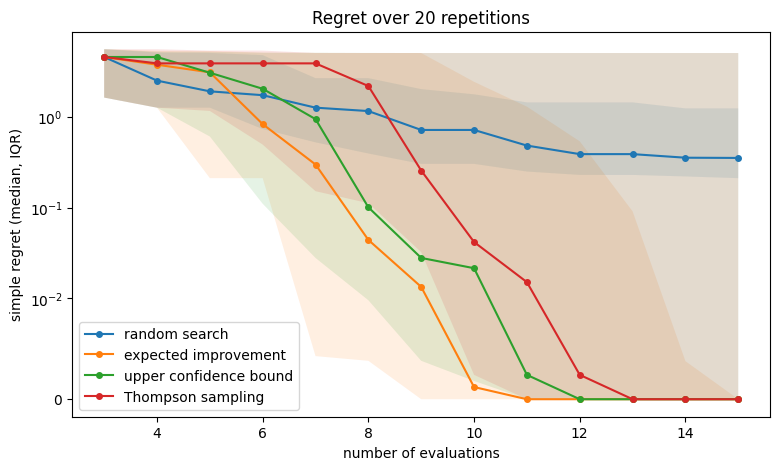

,median regret after 15 evaluations,runs within 0.05 of the maximum
random search,0.351959,15%
expected improvement,0.0,80%
upper confidence bound,0.0,70%
Thompson sampling,0.0,65%


In [3]:
def optimize(strategy, seed, iters=12):
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 1, (3, 1))
    y = f(X).ravel()
    best = [y.max()]
    for t in range(iters):
        if strategy == "random search":
            x_next = rng.uniform(0, 1, (1, 1))
        else:
            gp = GP("matern52").fit(X, y, restarts=3, seed=seed)
            if strategy == "expected improvement":
                score = expected_improvement(gp, grid, y.max())
            elif strategy == "upper confidence bound":
                score = upper_confidence_bound(gp, grid, beta=2.0)
            else:
                score = gp.sample(grid, 1, seed=1000 * seed + t).ravel()
            x_next = grid[[score.argmax()]]
        X = np.vstack([X, x_next])
        y = np.append(y, f(x_next).ravel())
        best.append(y.max())
    return f_max - np.array(best)

strategies = ["random search", "expected improvement", "upper confidence bound", "Thompson sampling"]
regret = {s: np.array([optimize(s, seed) for seed in range(20)]) for s in strategies}

fig, ax = plt.subplots(figsize=(9, 5))
for s, r in regret.items():
    med = np.median(r, 0)
    ax.plot(np.arange(len(med)) + 3, med, "o-", ms=4, label=s)
    ax.fill_between(np.arange(len(med)) + 3, np.quantile(r, 0.25, 0), np.quantile(r, 0.75, 0), alpha=0.12)
ax.set_yscale("symlog", linthresh=0.01)
ax.set(xlabel="number of evaluations", ylabel="simple regret (median, IQR)",
       title="Regret over 20 repetitions")
ax.legend()
plt.show()

pd.DataFrame({s: {"median regret after 15 evaluations": np.median(r[:, -1]),
                  "runs within 0.05 of the maximum": f"{(r[:, -1] < 0.05).mean():.0%}"} for s, r in regret.items()}).T

All three acquisition functions converge to the global maximum within about 12 evaluations in most runs: expected improvement in 80% of the runs, UCB in 70% and Thompson sampling in 65%. Random search is still about 0.35 below the maximum after 15 evaluations and gets that close in only 15% of the runs. EI is the fastest here; Thompson sampling explores more at the start, which costs a few evaluations on a function with a single dominant peak.

The wide bands show that BO can also fail: in some runs the surrogate model is misled by the first points and keeps refining the local maximum near 0.14. More initial points, or a more exploratory acquisition, reduce that risk.

## 2. A real problem: the paper helicopter

A paper helicopter is cut from an A4 sheet: two rotor blades are formed by a vertical **cut**, and the body is narrowed by trimming its sides. Three design parameters (in cm) were varied:

- **cut height**: length of the cut that forms the rotors (at most half the page, 14.85 cm);
- **trim height** and **trim width**: size of the rectangle removed from the body (the trim cannot be longer than the cut, and at most a third of the page wide, 7 cm).

Each helicopter was dropped from the same height and its **flight time** (s) measured with a stopwatch. The data were collected in two rounds: an initial set of 19 flights, and a second round of 18 flights chosen to explore promising designs.

       count  mean   max
round                   
1         19  3.03  3.95
2         18  3.40  3.99

designs flown more than once: 9; pooled standard deviation between repeated flights: 0.15 s


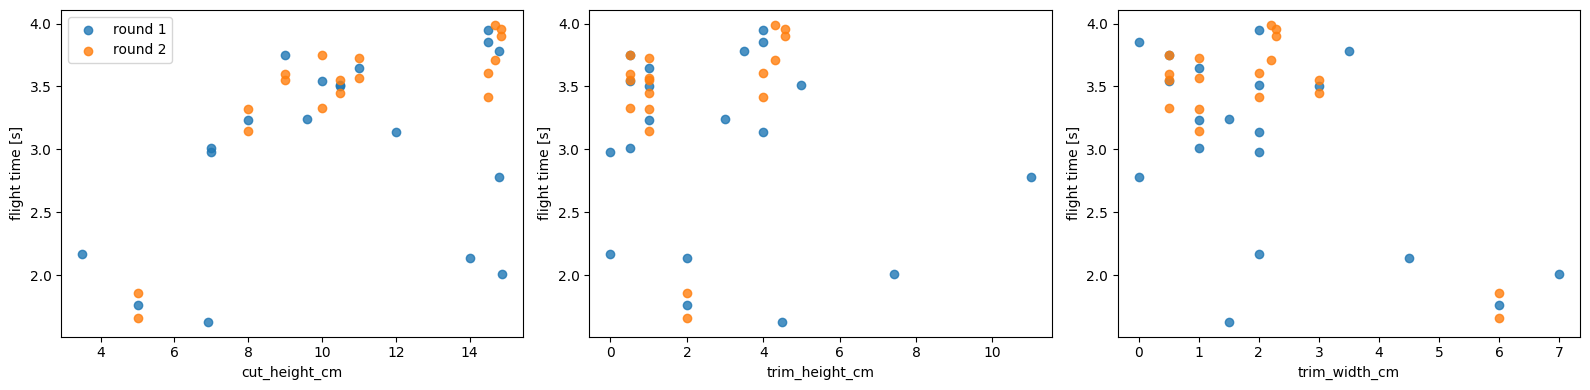

In [4]:
heli = pd.read_csv("data/paper_helicopter.csv")
features = ["cut_height_cm", "trim_height_cm", "trim_width_cm"]
print(heli.groupby("round")["flight_time_s"].agg(["count", "mean", "max"]).round(2))

repeats = heli.groupby(features)["flight_time_s"].agg(["count", "var"]).query("count > 1")
noise_var = (repeats["var"] * (repeats["count"] - 1)).sum() / (repeats["count"] - 1).sum()
print(f"\ndesigns flown more than once: {len(repeats)}; pooled standard deviation between repeated flights: {np.sqrt(noise_var):.2f} s")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, features):
    for r, color in [(1, "tab:blue"), (2, "tab:orange")]:
        sub = heli[heli["round"] == r]
        ax.scatter(sub[col], sub["flight_time_s"], color=color, label=f"round {r}", alpha=0.8)
    ax.set(xlabel=col, ylabel="flight time [s]")
axes[0].legend()
fig.tight_layout()
plt.show()

- Flight times range from about 1.6 to 4 seconds. The best helicopters have a **long cut** (long rotor blades) and a moderate trim height around 4 cm; short cuts give clearly worse flights.
- Repeating the same design gives times that differ by about **0.15 s**. This is the measurement noise of the experiment (hand release and stopwatch), and no model should try to explain differences smaller than that.
- The second round concentrated on promising regions and has a higher average flight time, as expected from an exploitative search.

### Choosing the surrogate model

Before trusting a GP to guide experiments, we check how well it predicts flights it has not seen. Two choices matter:

- inputs are rescaled to $[0, 1]$ (dividing by the maximum allowed value of each parameter), so that the lengthscales are comparable;
- the **noise variance is fixed** to the value measured from the repeated flights. With so few data points, letting the marginal likelihood estimate the noise tends to drive it to almost zero: the GP then interpolates every flight exactly and mistakes stopwatch noise for structure.

We compare three kernels with **leave-one-out cross-validation**: each flight is predicted by a GP fitted on all the others. We do it twice, on the first round only (the information available when planning the second round) and on all flights.

In [5]:
upper = np.array([14.85, 14.85, 7.0])
round1 = heli[heli["round"] == 1]
X1, y1 = round1[features].to_numpy() / upper, round1["flight_time_s"].to_numpy()

X_all, y_all = heli[features].to_numpy() / upper, heli["flight_time_s"].to_numpy()

def loo_rmse(kernel, X, y):
    errors = []
    for i in range(len(y)):
        keep = np.arange(len(y)) != i
        gp = GP(kernel).fit(X[keep], y[keep], restarts=4, noise=noise_var)
        errors.append(y[i] - gp.predict(X[i:i + 1])[0][0])
    return np.sqrt(np.mean(np.square(errors)))

loo = pd.DataFrame({
    k: {"round 1 only (19 flights)": loo_rmse(k, X1, y1), "all flights (37)": loo_rmse(k, X_all, y_all)}
    for k in ["rbf", "matern52", "linear"]
}).T
loo.loc["predicting the mean"] = [y1.std(), y_all.std()]
loo.round(3)

,round 1 only (19 flights),all flights (37)
rbf,0.656,0.374
matern52,0.613,0.420
linear,0.534,0.397
predicting the mean,0.726,0.699


In [6]:
gp1 = GP("rbf").fit(X1, y1, restarts=20, noise=noise_var)
pd.Series({**{f"lengthscale ({c})": l for c, l in zip(features, gp1.lengthscales)},
           "signal std [s]": np.sqrt(gp1.variance), "noise std [s]": np.sqrt(gp1.noise)}).round(3)

lengthscale (cut_height_cm)       0.109
lengthscale (trim_height_cm)      0.093
lengthscale (trim_width_cm)     403.429
signal std [s]                    0.697
noise std [s]                     0.147
dtype: float64

With the 19 flights of the first round, no kernel predicts left-out flights much better than simply predicting the average: the data are too sparse in three dimensions, and a few surprising flights (for example a long cut with a wide trim that flew only 2.1 s) have no neighbours to learn from. With all 37 flights the picture changes: the RBF kernel halves the error relative to the mean (0.37 s vs 0.70 s), and it becomes a useful surrogate. **The second round mattered as much for the model as for the helicopter.**

The fitted lengthscales measure how quickly the flight time changes along each (rescaled) parameter. Cut height and trim height have short lengthscales: they matter a lot. The lengthscale of trim width is enormous, which means the model treats trim width as **irrelevant**. Caution is needed, though: the few designs with a wide trim also had short cuts, so their poor flights can be explained by the cut alone. The two effects are **confounded** in this dataset, and only an experiment that varies trim width while keeping the cut long could separate them.

### What the model has learned

Since trim width hardly matters, we can visualize the fitted surface as a function of cut height and trim height, with trim width fixed at its median.

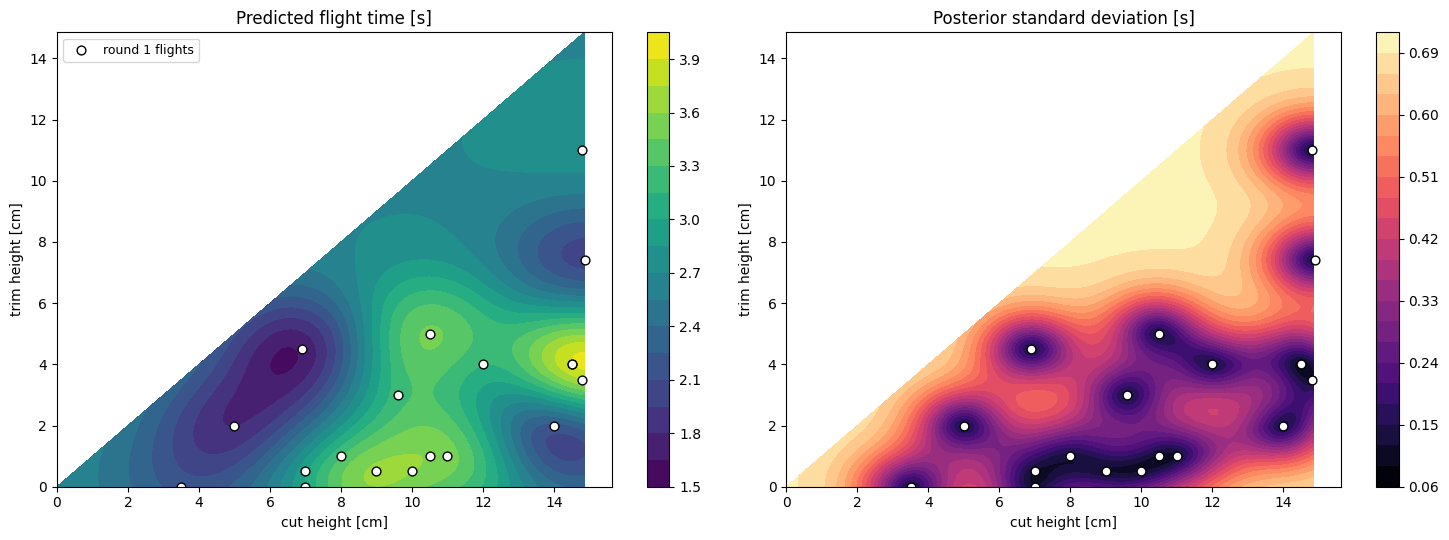

In [7]:
ch, th = np.meshgrid(np.linspace(0, 1, 120), np.linspace(0, 1, 120))
valid = th <= ch
grid3 = np.column_stack([ch.ravel(), th.ravel(), np.full(ch.size, np.median(X1[:, 2]))])
mu, var = gp1.predict(grid3)
mu, sd = np.where(valid.ravel(), mu, np.nan).reshape(ch.shape), np.where(valid.ravel(), np.sqrt(var), np.nan).reshape(ch.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, Z, title, cmap in [(axes[0], mu, "Predicted flight time [s]", "viridis"), (axes[1], sd, "Posterior standard deviation [s]", "magma")]:
    cs = ax.contourf(ch * upper[0], th * upper[1], Z, levels=20, cmap=cmap)
    fig.colorbar(cs, ax=ax)
    ax.scatter(round1["cut_height_cm"], round1["trim_height_cm"], color="white", edgecolor="black", s=40, label="round 1 flights")
    ax.set(xlabel="cut height [cm]", ylabel="trim height [cm]", title=title)
axes[0].legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

The predicted flight time is highest for a cut close to the maximum (about 14.5–14.85 cm) with a trim height around 4 cm, a region already visited by the best flights of the first round. A second, broader good region appears for medium cuts (9–11 cm) with very small trims. Short cuts are clearly bad.

The uncertainty map shows where the data are: the model is confident near the flights and very uncertain in the upper part of the triangle (long trims), which the first round barely explored.

### Proposing the next experiments

We now let each acquisition function propose the next design, using only the first round. The candidates are 20,000 random designs that satisfy the constraints (trim height ≤ cut height), and we report the best one for each acquisition function.

In [8]:
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (20_000, 3))
cand = cand[cand[:, 1] <= cand[:, 0]]

proposals = {
    "expected improvement": cand[expected_improvement(gp1, cand, y1.max()).argmax()],
    "UCB (beta = 2)": cand[upper_confidence_bound(gp1, cand, beta=2.0).argmax()],
    "Thompson sampling": cand[np.argmax(gp1.sample(cand[:3000], 1, seed=1).ravel())],
}
rows = {}
for name, x in proposals.items():
    m, v = gp1.predict(x[None])
    rows[name] = dict(zip(features, np.round(x * upper, 2)), **{"predicted time [s]": m[0], "predicted std [s]": np.sqrt(v[0])})
pd.DataFrame(rows).T.round(2)

,cut_height_cm,trim_height_cm,trim_width_cm,predicted time [s],predicted std [s]
expected improvement,14.82,4.34,1.87,3.92,0.22
UCB (beta = 2),14.85,4.66,5.60,3.79,0.31
Thompson sampling,8.72,0.12,0.24,3.60,0.21


The three acquisition functions behave as expected:

- **Expected improvement** proposes a design right next to the best flights (cut 14.8 cm, trim height 4.3 cm), where the model is confident it can improve slightly: mostly **exploitation**.
- **UCB** chooses a similar cut and trim height but a wide trim, where the model is more uncertain (standard deviation 0.31 s): it is willing to pay for **information** about trim width, which is exactly the open question raised by the confounding above.
- **Thompson sampling** draws one plausible function and picks its maximizer, here in the second good region with a medium cut. Its randomness spreads proposals across all regions that might be optimal.

### Did the second round help?

The second round of 18 flights explored designs with long cuts and longer trims. We refit the GP on all 37 flights and compare what we know before and after.

In [9]:
gp_all = GP("rbf").fit(X_all, y_all, restarts=20, noise=noise_var)

best_design = cand[gp_all.predict(cand)[0].argmax()]
m_best, v_best = gp_all.predict(best_design[None])
round2 = heli[heli["round"] == 2]
m_r2 = gp1.predict(round2[features].to_numpy() / upper)[0]

print(f"round 2 flights predicted by the round-1 model: RMSE {np.sqrt(np.mean((round2['flight_time_s'] - m_r2) ** 2)):.2f} s")
print(f"best single flight: round 1 {round1['flight_time_s'].max():.2f} s, round 2 {round2['flight_time_s'].max():.2f} s")
print("lengthscales after both rounds:", dict(zip(features, gp_all.lengthscales.round(2))))
print(f"\ndesign with the highest predicted mean flight time (all data): "
      f"{dict(zip(features, (best_design * upper).round(2)))}")
print(f"predicted flight time: {m_best[0]:.2f} s  +/- {2 * np.sqrt(v_best[0]):.2f} s")

round 2 flights predicted by the round-1 model: RMSE 0.18 s
best single flight: round 1 3.95 s, round 2 3.99 s
lengthscales after both rounds: {'cut_height_cm': 0.1, 'trim_height_cm': 0.12, 'trim_width_cm': 385.7}

design with the highest predicted mean flight time (all data): {'cut_height_cm': 14.83, 'trim_height_cm': 4.25, 'trim_width_cm': 4.22}
predicted flight time: 3.92 s  +/- 0.14 s


The round-1 model predicted the 18 second-round flights with an error of about 0.18 s, close to the measurement noise: in the regions the second round explored, the model was already reliable. The best flight improved only slightly, from 3.95 to 3.99 s, a difference well below the noise between repeated flights.

With all the data, the model's best design has a cut of about 14.8 cm (the maximum) and a trim height of about 4.3 cm, with a predicted mean flight time of 3.9 ± 0.14 s. The conclusion is that the first round had already found a near-optimal region, and the second round confirmed it and reduced the uncertainty around it. A larger improvement would require changing something the experiment did not vary, such as the paper weight or the blade shape.

## Summary

- Bayesian optimization replaces blind search with a loop of **model → acquisition → evaluation**, and it is most valuable when every evaluation is expensive.
- **Expected improvement**, **UCB** and **Thompson sampling** balance exploration and exploitation differently; all clearly beat random search on a smooth function.
- On real data, the surrogate model must be **validated** (here with leave-one-out) and the **measurement noise** quantified (here with repeated flights). The GP's lengthscales also reveal which design variables matter.
- **Constraints** on the design space are easily handled by restricting the candidate set.